## **Telecom Customer Churn Prediction and Analysis**

#### **PROBLEM STATEMENT**

Customer churn refers to customers who stop using a company's services.
The objective of this project is to predict whether a telecom customer will churn or not using historical customer data.
By identifying customers likely to churn, companies can take preventive actions such as offering discounts or improving services.

#### **DATASET DESCRIPTION**

The dataset contains information about telecom customers, including demographic details, account information, and service usage.
Each row represents a customer and each column represents a feature describing that customer.

##### **Key Features**

- **gender** : Customer gender
- **SeniorCitizen** : Whether the customer is a senior citizen
- **tenure** : Number of months the customer has stayed with the company
- **MonthlyCharges** : Monthly service charges
- **TotalCharges** : Total amount charged to the customer
- **Contract** : Contract type
- **InternetService** : Type of internet service used
- **PaymentMethod** : Payment method used by the customer
- **Churn** : Whether the customer left the company

##### **Target Variable**
**Churn**

- Yes → Customer left the service
- No → Customer stayed with the company

#### **INITIAL EDA**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df = pd.read_csv("../data/telco_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.shape

(7043, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [9]:
#Numerical variables
df.select_dtypes(include=['int64','float64']).columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')

In [10]:
#Categorical variables
df.select_dtypes(include='object').columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')

In [11]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


#### **DISTRIBUTION OF CUSTOMER TENURE**

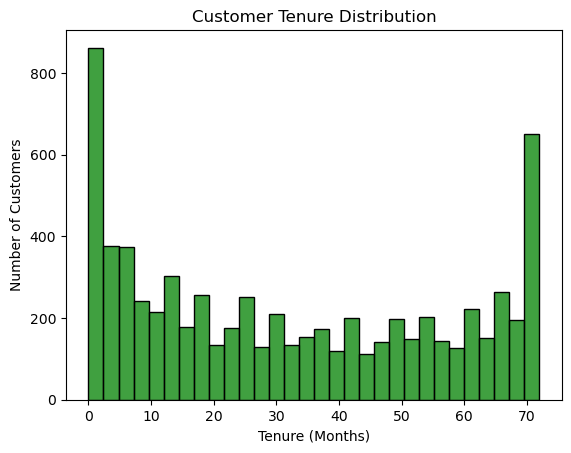

In [13]:
sns.histplot(df['tenure'], bins=30 , color = 'green')
plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()

#### **CHURN DISTRIBUTION**

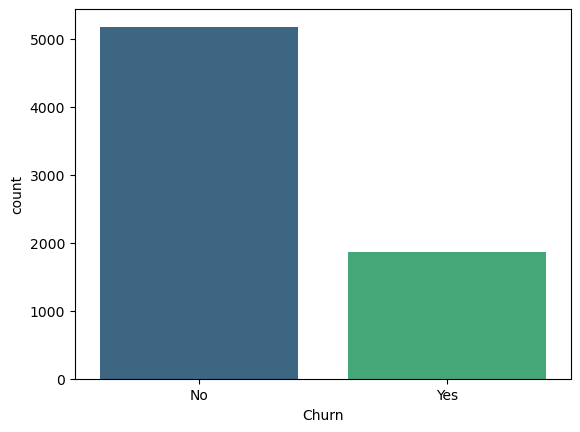

In [14]:
# This visualization shows the number of customers who stayed and those who churned.

sns.countplot(x='Churn',data=df,hue = 'Churn', palette = 'viridis')
plt.show()

#### **MONTHLY CHARGES DISTRIBUTION**

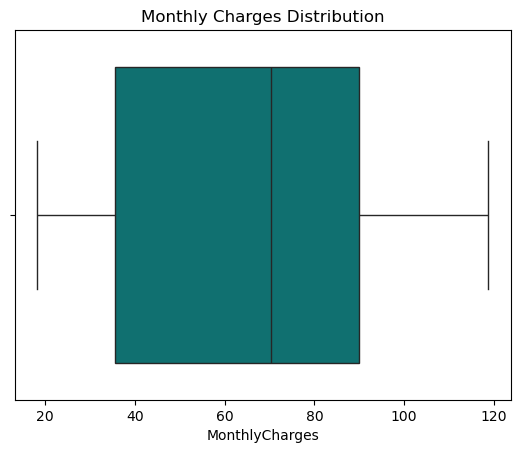

In [15]:
sns.boxplot(x=df['MonthlyCharges'], color = 'teal')
plt.title("Monthly Charges Distribution")
plt.show()

#### **TENURE VS MONTHLY CHARGES**

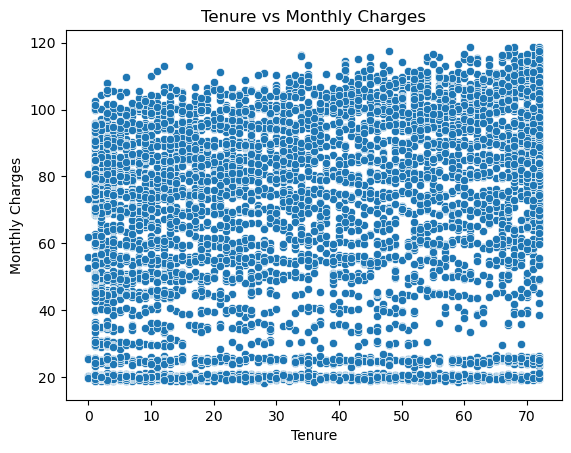

In [16]:
sns.scatterplot(x='tenure', y='MonthlyCharges', data=df)
plt.title("Tenure vs Monthly Charges")
plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")
plt.show()

#### **CORRELATION HEATMAP**

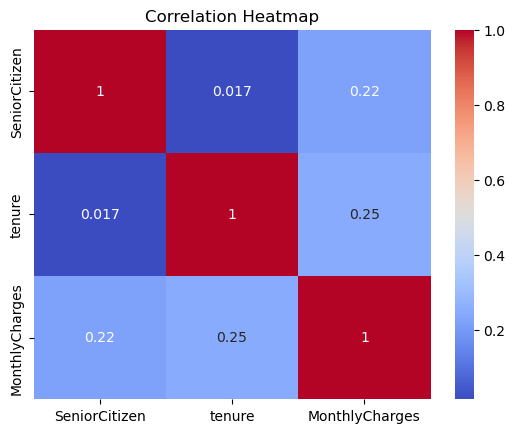

In [373]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#### **CUSTOMER CHURN BY DATATYPE**

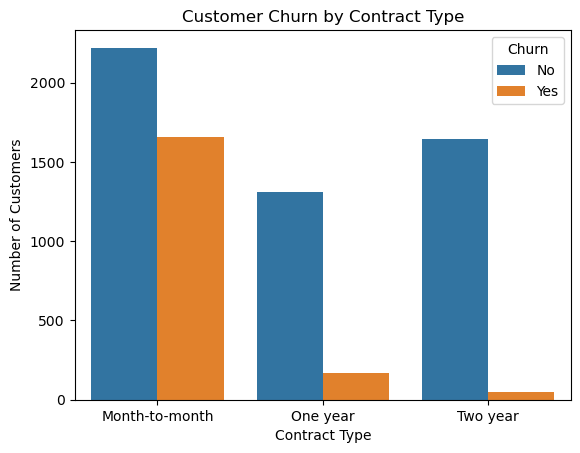

In [374]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

#### **CHURN VS TENURE**

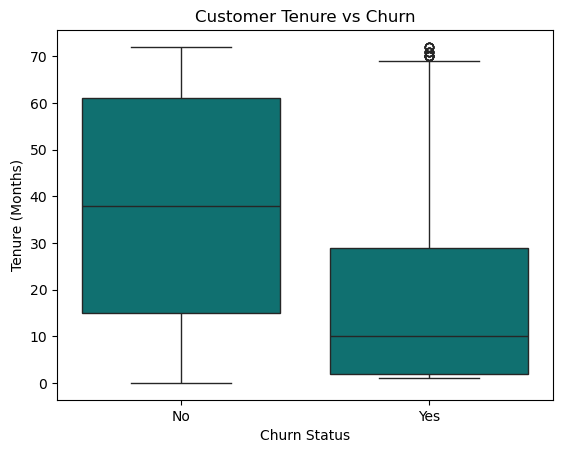

In [17]:
sns.boxplot(x='Churn', y='tenure', data=df, color = 'teal')
plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn Status")
plt.ylabel("Tenure (Months)")
plt.show()

### **DATA CLEANING & PREPROCESSING**

#### Fixing Datatypes

In [376]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [377]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

#### Handling Missing Values

In [378]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [379]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

#### Handling Duplicate Values

In [380]:
df.duplicated().sum()

np.int64(0)

#### Removing Unwanted Columns

In [381]:
df.drop('customerID',axis = 1, inplace = True)

#### Checking Value Consistency

In [382]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [383]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [384]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

#### Encode Categorical Variable 

In [385]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [386]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [387]:
df = pd.get_dummies(df, drop_first = True).astype(int)

In [388]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29,29,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56,1889,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53,108,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42,1840,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70,151,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


In [389]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   SeniorCitizen                          7043 non-null   int64
 1   tenure                                 7043 non-null   int64
 2   MonthlyCharges                         7043 non-null   int64
 3   TotalCharges                           7043 non-null   int64
 4   Churn                                  7043 non-null   int64
 5   gender_Male                            7043 non-null   int64
 6   Partner_Yes                            7043 non-null   int64
 7   Dependents_Yes                         7043 non-null   int64
 8   PhoneService_Yes                       7043 non-null   int64
 9   MultipleLines_No phone service         7043 non-null   int64
 10  MultipleLines_Yes                      7043 non-null   int64
 11  InternetService_Fiber optic   

In [390]:
df.shape

(7043, 31)

### Issues Found in the Dataset

During the initial inspection of the dataset, a few issues were identified:

* The **TotalCharges** column was stored as an `object` datatype instead of a numerical datatype.
* Some entries in **TotalCharges** contained **missing or blank values**, which resulted in `NaN` values after conversion.
* The dataset contained a **customerID column**, which is only an identifier and does not contribute to predictive modeling.
* Several variables were **categorical**, which cannot be directly used by machine learning algorithms.

### Cleaning Decisions Made

To address the issues identified in the dataset, the following steps were performed:

* The **TotalCharges** column was converted from `object` to a numeric datatype using `pd.to_numeric()`.
* Missing values in **TotalCharges** were filled using the **median value** of the column to maintain the distribution of the data.
* The **customerID** column was removed since it does not provide useful information for prediction.
* The **Churn** column was encoded into binary values (`Yes → 1`, `No → 0`) since it is the target variable.
* Remaining categorical variables were converted into numerical form using **One-Hot Encoding**.

### Assumptions Taken During Preprocessing

The following assumptions were made while cleaning the dataset:

* Missing values in **TotalCharges** were assumed to be minimal and were replaced using the **median**, which is robust to outliers.
* The **customerID** column was assumed to have no predictive value and was therefore removed.
* One-hot encoding was applied to categorical variables assuming that there is **no ordinal relationship between categories**.
* The parameter `drop_first=True` was used during encoding to avoid **multicollinearity** in the model.
